# simple_refridgeration4_plr

This notebook is a PLR-enabled variant of `simple_refridgeration4.ipynb` and uses `SimpleVaporCompressionCyclePLR` from `vapor_compression_plr`.

**Acknowledgment:** Modified by Codex at user request.


In [1]:
from vapor_compression_plr import SimpleVaporCompressionCyclePLR, Mode
import numpy as np
import matplotlib.pyplot as plt

## Define Workflow

| Refrigerant | IDAES | CoolProp |
| --- | --- | --- |
| CO2 | Yes | Yes | 
| Propane | Yes | Yes |
| R32 | Yes | Yes |
| R125 | Yes | Yes |
| R134a | Yes | Yes |
| R227ea | Yes | Yes |
| R1234ze | Yes | Yes |



In [2]:
def analyze_refrigerant(working_fluid='R227ea', run_sensitivity=True, plr=0.2, cd=0.13):
    """
    Analyze the refrigerant properties for a given working fluid.

    Parameters
    ----------
    working_fluid : str
        Refrigerant name.
    run_sensitivity : bool
        Whether to run ambient sweep.
    plr : float
        Part-load ratio in [0, 1]. Required for PLR/COP_part.
    cd : float
        Cyclic degradation coefficient in [0.05, 0.5].
    """

    # Create a SimpleVaporCompressionCyclePLR object
    vc = SimpleVaporCompressionCyclePLR(working_fluid, mode=Mode.PH)
    
    # Draw thermodynamic diagrams
    vc.draw_thermodynamic_diagrams()

    # Specify cycle parameters
    vc.specify_initial_conditions(low_side_temperature=0,
                              high_side_temperature=20)

    # Initialize
    vc.initialize(verbose=True)

    # Set specifications
    vc.set_specifications(
    low_side_pressure=(20, 300), # Pa
    high_side_pressure=(500, 2000), # Pa
    evaporator_temperature=(-20, 0), # degC
    condenser_temperature=(30, 40), # degC
    subcooling = 3, # deg C
    superheating = 3 # deg C
    )

    # # Report results
    # vc.report_solution()

    if run_sensitivity:

        T_ambient = np.linspace(20, 30, 21)

        COP = np.zeros_like(T_ambient)
        opt_converged = np.zeros_like(T_ambient, dtype=bool)

        for i, Ta in enumerate(T_ambient):
            try:
                vc.set_specifications(
                    low_side_pressure=(20, 300),
                    high_side_pressure=(500, 2000),
                    evaporator_temperature=(-20, 0),
                    condenser_temperature=(Ta+5, Ta+15),
                    subcooling=3,
                    superheating=3,
                    plr=plr,
                    cd=cd,
                )
                # print(f"\n\nConsidering ambient temperature of {Ta} C...")
                
                # print("class:", type(vc))
                # print("plr, cd:", vc.plr, vc.cd)
                # print("fs.PLR, fs.CD, fs.PLF:", value(vc.model.fs.PLR), value(vc.model.fs.CD),
                # value(vc.model.fs.PLF))
            
                # cop, conv = vc.optimize_COP(verbose=False, initialize=False)
                # print("optimize_COP return:", cop, "converged:", conv)
                # print("COP_full:", value(vc.model.fs.COP_full), "COP_part:",
                # value(vc.model.fs.COP_part))



                COP[i], opt_converged[i] = vc.optimize_COP(verbose=False, initialize=False)
                COP[i] = vc.get_part_load_cop()
            except:
                COP[i] = np.nan
                opt_converged[i] = False

        j = opt_converged
        plt.plot(T_ambient[j], COP[j], linewidth=3, marker='o',color="blue")
        plt.plot(T_ambient[~j], COP[~j], linewidth=3, marker='x',color="red")
        plt.xlabel('Ambient temperature (°C)', fontsize=28)
        plt.ylabel('COP', fontsize=28)
        # plt.title(f'Simple Vapor Compression with {working_fluid}', fontsize=18)
        plt.grid()
        plt.savefig("cop_vs_ambient_plr.pdf", format="pdf", bbox_inches="tight")
        plt.show()


    


## R227ea

In [3]:
# analyze_refrigerant('R134a')

## R134a

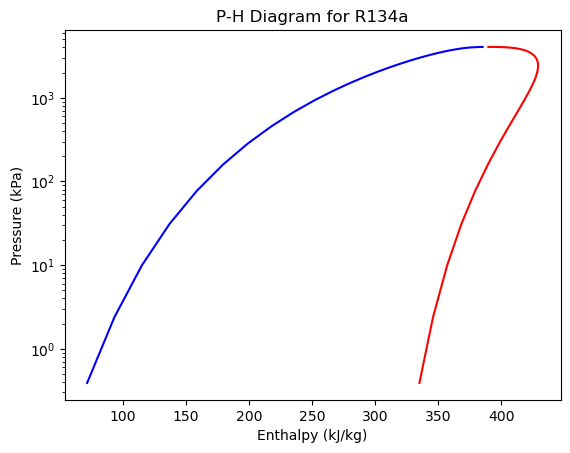

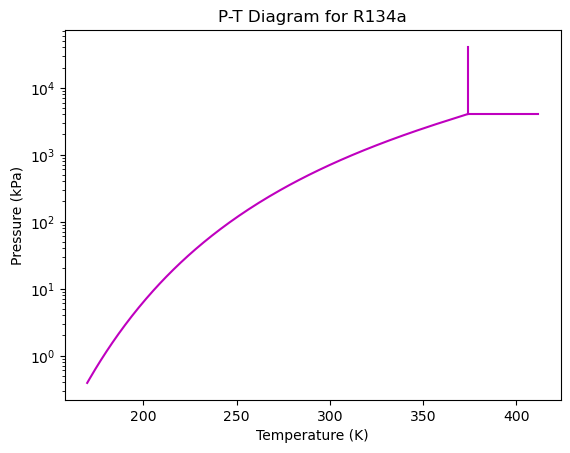

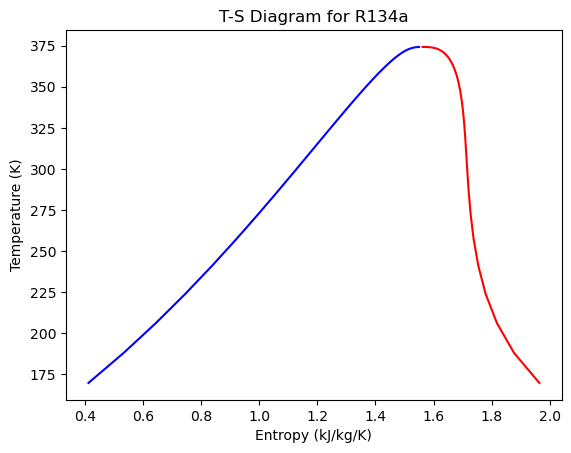

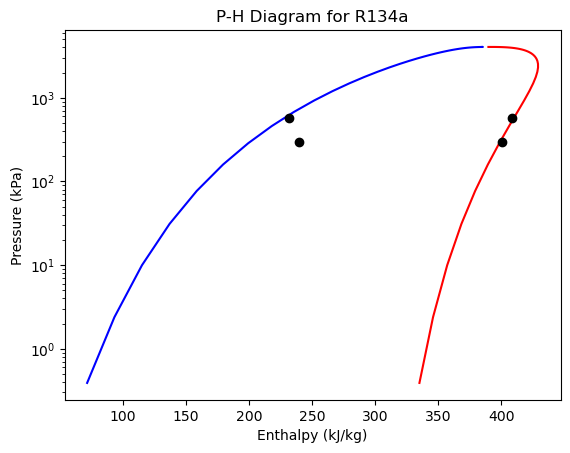

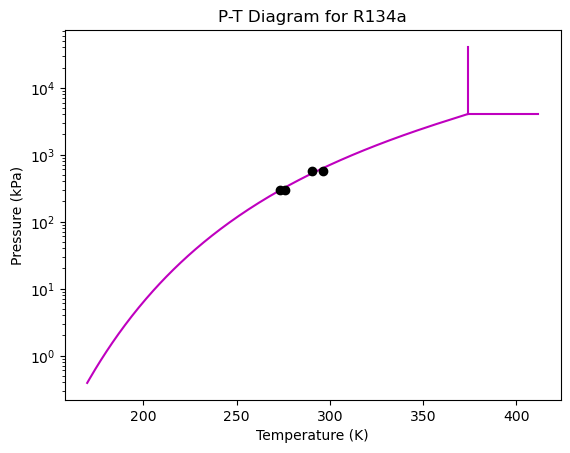

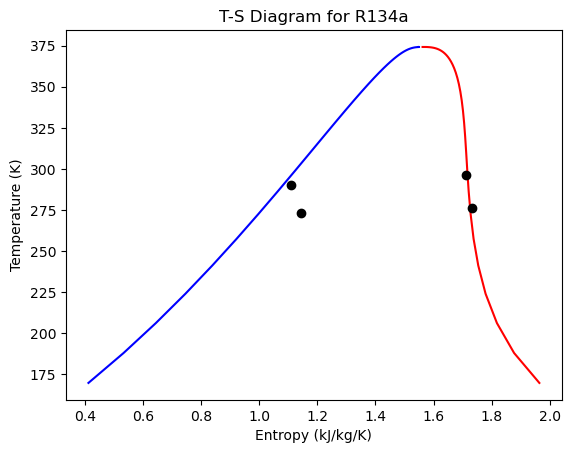


Unit : fs.evaporator                                                       Time: 0.0
------------------------------------------------------------------------------------
    Unit Performance

    Variables: 

    Key       : Value      : Units : Fixed : Bounds
    Heat Duty : 1.6062e+05 :  watt : False : (None, None)

------------------------------------------------------------------------------------
    Stream Table
                         Units           Inlet     Outlet  
    Molar Flow          mole / second     9.8008     9.8008
    Mass Flow       kilogram / second     1.0000     1.0000
    T                          kelvin     273.15     275.09
    P                          pascal 2.9280e+05 2.9280e+05
    Vapor Fraction      dimensionless    0.20000     1.0000
    Mass Enthalpy    joule / kilogram 2.3972e+05 4.0034e+05


  - termination condition: infeasible
  - message from solver: Ipopt 3.13.2\x3a Converged to a locally infeasible point. Problem may be infeasible.



Unit : fs.compressor                                                       Time: 0.0
------------------------------------------------------------------------------------
    Unit Performance

    Variables: 

    Key                   : Value      : Units         : Fixed : Bounds
    Isentropic Efficiency :    0.60000 : dimensionless :  True : (None, None)
          Mechanical Work :     23254. :          watt : False : (None, None)
          Pressure Change : 2.7890e+05 :        pascal : False : (None, None)
           Pressure Ratio :     1.9525 : dimensionless : False : (None, None)

------------------------------------------------------------------------------------
    Stream Table
                         Units           Inlet     Outlet  
    Molar Flow          mole / second     9.8008     9.8008
    Mass Flow       kilogram / second     1.0000     1.0000
    T                          kelvin     275.09     307.27
    P                          pascal 2.9280e+05 5.7171e+05
   

2026-02-23 23:56:08 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.compressor.control_volume.work


2026-02-23 23:56:08 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.condenser.control_volume.heat


2026-02-23 23:56:08 [WARNING] idaes.core.util.scaling: Missing scaling factor for fs.expansion_valve.control_volume.work


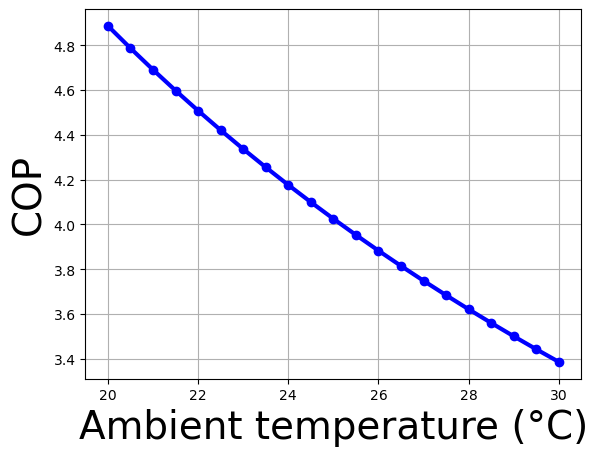

In [4]:
analyze_refrigerant('R134a')

## R32

In [5]:
# Initialization fails with out of bounds enthalpy error
# Optimization and sensitivity analyses do not run
# analyze_refrigerant('R32')

## R125

In [6]:
# Ipopt always fails to converge
# analyze_refrigerant('R125', run_sensitivity=False)

## R1234ze

In [7]:
# Refrigerant name is not consistent across CoolProp and IDAES?
# analyze_refrigerant('R1234ze')

## CO2

In [8]:
# Ipopt always fails to converge
# analyze_refrigerant('CO2', run_sensitivity=False)

## Propane

In [9]:
# Fails to converge for higher ambient temperatures
# analyze_refrigerant('propane')